# # 線性迴歸
:label:`sec_linear_regression`

*迴歸*（regression）是能為一個或多個自變量與因變量之間關係建模的一類方法。
在自然科學和社會科學領域，迴歸經常用來表示輸入和輸出之間的關係。

在機器學習領域中的大多數任務通常都與*預測*（prediction）有關。
當我們想預測一個數值時，就會涉及到迴歸問題。
常見的例子包括：預測價格（房屋、股票等）、預測住院時間（針對住院病人等）、
預測需求（零售銷量等）。
但不是所有的*預測*都是迴歸問題。
在後面的章節中，我們將介紹分類問題。分類問題的目標是預測數據屬於一組類別中的哪一個。

## 線性迴歸的基本元素

*線性迴歸*（linear regression）可以追溯到19世紀初，
它在迴歸的各種標準工具中最簡單而且最流行。
線性迴歸基於幾個簡單的假設：
首先，假設自變量$\mathbf{x}$和因變量$y$之間的關係是線性的，
即$y$可以表示為$\mathbf{x}$中元素的加權和，這裡通常允許包含觀測值的一些雜訊；
其次，我們假設任何雜訊都比較正常，如雜訊遵循常態分布。

為了解釋*線性迴歸*，我們舉一個實際的例子：
我們希望根據房屋的面積（平方英尺）和房齡（年）來估算房屋價格（美元）。
為了開發一個能預測房價的模型，我們需要收集一個真實的資料集。
這個資料集包括了房屋的銷售價格、面積和房齡。
在機器學習的術語中，該資料集稱為*訓練資料集*（training data set）
或*訓練集*（training set）。
每行資料（比如一次房屋交易相對應的資料）稱為*樣本*（sample），
也可以稱為*資料點*（data point）或*資料樣本*（data instance）。
我們把試圖預測的目標（比如預測房屋價格）稱為*標籤*（label）或*目標*（target）。
預測所依據的自變量（面積和房齡）稱為*特徵*（feature）或*共變量*（covariate）。

通常，我們使用$n$來表示資料集中的樣本數。
對索引為$i$的樣本，其輸入表示為$\mathbf{x}^{(i)} = [x_1^{(i)}, x_2^{(i)}]^\top$，
其對應的標籤是$y^{(i)}$。

### 線性模型
:label:`subsec_linear_model`

線性假設是指目標（房屋價格）可以表示為特徵（面積和房齡）的加權和，如下面的式子：

$$\mathrm{price} = w_{\mathrm{area}} \cdot \mathrm{area} + w_{\mathrm{age}} \cdot \mathrm{age} + b.$$
:eqlabel:`eq_price-area`

 :eqref:`eq_price-area`中的$w_{\mathrm{area}}$和$w_{\mathrm{age}}$
稱為權重（weight），權重決定了每個特徵對我們預測值的影響。
$b$稱為*偏置*（bias）、*偏移量*（offset）或*截距*（intercept）。
偏置是指當所有特徵都取值為0時，預測值應該為多少。
即使現實中不會有任何房子的面積是0或房齡正好是0年，我們仍然需要偏置項。
如果沒有偏置項，我們模型的表達能力將受到限制。
嚴格來說， :eqref:`eq_price-area`是輸入特徵的一個
*仿射變換*（affine transformation）。
仿射變換的特點是通過加權對特徵進行*線性變換*（linear transformation），
並通過偏置項進行*平移*（translation）。

給定一個資料集，我們的目標是尋找模型的權重$\mathbf{w}$和偏置$b$，
使得根據模型做出的預測大致符合資料裡的真實價格。
輸出的預測值由輸入特徵通過*線性模型*的仿射變換決定，仿射變換由所選權重和偏置確定。

而在機器學習領域，我們通常使用的是高維資料集，建模時採用線性代數表示法會比較方便。
當我們的輸入包含$d$個特徵時，我們將預測結果$\hat{y}$
（通常使用“尖角”符號表示$y$的估計值）表示為：

$$\hat{y} = w_1  x_1 + ... + w_d  x_d + b.$$

將所有特徵放到向量$\mathbf{x} \in \mathbb{R}^d$中，
並將所有權重放到向量$\mathbf{w} \in \mathbb{R}^d$中，
我們可以用點積形式來簡潔地表達模型：

$$\hat{y} = \mathbf{w}^\top \mathbf{x} + b.$$
:eqlabel:`eq_linreg-y`

在 :eqref:`eq_linreg-y`中，
向量$\mathbf{x}$對應於單個資料樣本的特徵。
用符號表示的矩陣$\mathbf{X} \in \mathbb{R}^{n \times d}$
可以很方便地引用我們整個資料集的$n$個樣本。
其中，$\mathbf{X}$的每一行是一個樣本，每一列是一種特徵。

對於特徵集合$\mathbf{X}$，預測值$\hat{\mathbf{y}} \in \mathbb{R}^n$
可以通過矩陣-向量乘法表示為：

$${\hat{\mathbf{y}}} = \mathbf{X} \mathbf{w} + b$$

這個過程中的求和將使用廣播機制
（廣播機制在 :numref:`subsec_broadcasting`中有詳細介紹）。
給定訓練資料特徵$\mathbf{X}$和對應的已知標籤$\mathbf{y}$，
線性迴歸的目標是找到一組權重向量$\mathbf{w}$和偏置$b$：
當給定從$\mathbf{X}$的同分布中取樣的新樣本特徵時，
這組權重向量和偏置能夠使得新樣本預測標籤的誤差盡可能小。

雖然我們相信給定$\mathbf{x}$預測$y$的最佳模型會是線性的，
但我們很難找到一個有$n$個樣本的真实資料集，其中對於所有的$1 \leq i \leq n$，$y^{(i)}$完全等於$\mathbf{w}^\top \mathbf{x}^{(i)}+b$。
無論我們使用什麼手段來觀察特徵$\mathbf{X}$和標籤$\mathbf{y}$，
都可能會出現少量的觀測誤差。
因此，即使確信特徵與標籤的潛在關係是線性的，
我們也會加入一個噪聲項來考慮觀測誤差帶來的影響。

在開始尋找最好的*模型參數*（model parameters）$\mathbf{w}$和$b$之前，
我們還需要兩個東西：
（1）一種模型質量的度量方式；
（2）一種能夠更新模型以提高模型預測質量的方法。

### 損失函數

在我們開始考慮如何用模型*擬合*（fit）資料之前，我們需要確定一個擬合程度的度量。
*損失函數*（loss function）能夠量化目標的*實際*值與*預測*值之間的差距。
通常我們會選擇非負數作為損失，且數值越小表示損失越小，完美預測時的損失為0。
迴歸問題中最常用的損失函數是平方誤差函數。
當樣本$i$的預測值為$\hat{y}^{(i)}$，其相應的真實標籤為$y^{(i)}$時，
平方誤差可以定義為以下公式：

$$l^{(i)}(\mathbf{w}, b) = \frac{1}{2} \left(\hat{y}^{(i)} - y^{(i)}\right)^2.$$
:eqlabel:`eq_mse`

常數$\frac{1}{2}$不會帶來本質的差別，但這樣在形式上稍微簡單一些
（因為當我們對損失函數求導後常數係數為1）。
由於訓練資料集並不受我們控制，所以經驗誤差只是關於模型參數的函數。
為了進一步說明，來看下面的例子。
我們為一維情況下的迴歸問題繪製圖像，如 :numref:`fig_fit_linreg`所示。

![用線性模型擬合資料。](../img/fit-linreg.svg)
:label:`fig_fit_linreg`

由於平方誤差函數中的二次方項，
估計值$\hat{y}^{(i)}$和觀測值$y^{(i)}$之間較大的差異將導致更大的損失。
為了度量模型在整個資料集上的質量，我們需計算在訓練集$n$個樣本上的損失均值（也等價於求和）。

$$L(\mathbf{w}, b) =\frac{1}{n}\sum_{i=1}^n l^{(i)}(\mathbf{w}, b) =\frac{1}{n} \sum_{i=1}^n \frac{1}{2}\left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right)^2.$$

在訓練模型時，我們希望尋找一組參數（$\mathbf{w}^*, b^*$），
這組參數能最小化在所有訓練樣本上的總損失。如下式：

$$\mathbf{w}^*, b^* = \operatorname*{argmin}_{\mathbf{w}, b}\  L(\mathbf{w}, b).$$

### 解析解

線性迴歸剛好是一個很簡單的優化問題。
與我們將在書中講到的其他大部分模型不同，線性迴歸的解可以用一個公式簡單地表達出來，
這類解叫作*解析解*（analytical solution）。
首先，我們將偏置$b$合併到參數$\mathbf{w}$中，合併方法是在包含所有參數的矩陣中附加一列。
我們的預測問題是最小化$\|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2$。
這在損失平面上只有一個臨界點，這個臨界點對應於整個區域的損失極小點。
將損失關於$\mathbf{w}$的導數設為0，得到解析解：

$$\mathbf{w}^* = (\mathbf X^\top \mathbf X)^{-1}\mathbf X^\top \mathbf{y}.$$

像線性迴歸這樣的簡單問題存在解析解，但並不是所有問題都存在解析解。
解析解可以進行很好的數學分析，但解析解對問題的限制很嚴格，導致它無法廣泛應用於深度學習中。

### 隨機梯度下降

即使在我們無法得到解析解的情況下，我們仍然可以有效地訓練模型。
在許多任務上，那些難以優化的模型效果要更好。
因此，弄清楚如何訓練這些難以優化的模型是非常重要的。

本書中我們用到一種名為*梯度下降*（gradient descent）的方法，
這種方法幾乎可以優化所有深度學習模型。
它透過不斷地在損失函數遞減的方向上更新參數來降低誤差。

梯度下降最簡單的用法是計算損失函數（資料集中所有樣本的損失均值）
關於模型參數的導數（在這裡也可以稱為梯度）。
但實際中的執行可能會非常慢：因為在每一次更新參數之前，我們必須遍歷整個資料集。
因此，我們通常會在每次需要計算更新時隨機抽取一小批樣本，
這種變體叫做*小批量隨機梯度下降*（minibatch stochastic gradient descent）。

在每次迭代中，我們首先隨機抽樣一小批樣本$\mathcal{B}$，
它是由固定數量的訓練樣本組成的。
然後，我們計算小批量的平均損失關於模型參數的導數（也可以稱為梯度）。
最後，我們將梯度乘以一個預先確定的正數$\eta$，並從當前參數的值中減掉。

我們用下面的數學公式來表示這一更新過程（$\partial$表示偏導數）：

$$(\mathbf{w},b) \leftarrow (\mathbf{w},b) - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \partial_{(\mathbf{w},b)} l^{(i)}(\mathbf{w},b).$$

總結一下，算法的步驟如下：
（1）初始化模型參數的值，如隨機初始化；
（2）從資料集中隨機抽取小批量樣本且在負梯度的方向上更新參數，並不斷迭代這一過程。
對於平方損失和仿射變換，我們可以明確地寫成如下形式:

$$\begin{aligned} \mathbf{w} &\leftarrow \mathbf{w} -   \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \partial_{\mathbf{w}} l^{(i)}(\mathbf{w}, b) = \mathbf{w} - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \mathbf{x}^{(i)} \left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right),\\ b &\leftarrow b -  \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \partial_b l^{(i)}(\mathbf{w}, b)  = b - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right). \end{aligned}$$
:eqlabel:`eq_linreg_batch_update`

公式 :eqref:`eq_linreg_batch_update`中的$\mathbf{w}$和$\mathbf{x}$都是向量。
在這裡，更優雅的向量表示法比係數表示法（如$w_1, w_2, \ldots, w_d$）更具可讀性。
$|\mathcal{B}|$表示每個小批量中的樣本數，這也稱為*批量大小*（batch size）。
$\eta$表示*學習率*（learning rate）。
批量大小和學習率的值通常是手動預先指定，而不是透過模型訓練得到的。
這些可以調整但不在訓練過程中更新的參數稱為*超參數*（hyperparameter）。
*調參*（hyperparameter tuning）是選擇超參數的過程。
超參數通常是我們根據訓練迭代結果來調整的，
而訓練迭代結果是在獨立的*驗證資料集*（validation dataset）上評估得到的。

在訓練了預先確定的若干迭代次數後（或者直到滿足某些其他停止條件後），
我們記錄下模型參數的估計值，表示為$\hat{\mathbf{w}}, \hat{b}$。
但是，即使我們的函數確實是線性的且無噪聲，這些估計值也不會使損失函數真正地達到最小值。
因為算法會使得損失向最小值緩慢收斂，但卻不能在有限的步數內非常精確地達到最小值。

線性迴歸恰好是一個在整個域中只有一個最小值的學習問題。
但是對像深度神經網路這樣複雜的模型來說，損失平面上通常包含多個最小值。
深度學習實踐者很少會去花大力氣尋找這樣一組參數，使得在*訓練集*上的損失達到最小。
事實上，更難做到的是找到一組參數，這組參數能在我們從未見過的資料上實現較低的損失，
這一挑戰被稱為*泛化*（generalization）。

### 用模型進行預測

給定“已學習”的線性迴歸模型$\hat{\mathbf{w}}^\top \mathbf{x} + \hat{b}$，
現在我們可以透過房屋面積$x_1$和房齡$x_2$來估計一個（未包含在訓練資料中的）新房屋價格。
給定特徵估計目標的過程通常稱為*預測*（prediction）或*推斷*（inference）。

本書將嘗試堅持使用*預測*這個詞。
雖然*推斷*這個詞已經成為深度學習的標準術語，但其實*推斷*這個詞有些用詞不當。
在統計學中，*推斷*更多地表示基於資料集估計參數。
當深度學習從業者與統計學家交談時，術語的誤用經常導致一些誤解。

## 矢量化加速

在訓練我們的模型時，我們經常希望能夠同時處理整個小批量的樣本。
為了實現這一點，需要(**我們對計算進行矢量化，從而利用線性代數庫，而不是在Python中編寫開銷高昂的for循環**)。


In [2]:
! pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.2.0-py3-none-any.whl.metadata (5.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 2.2 MB/s eta 0:00:00a 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 1.1 MB/s eta 0:00:00a 0:00:010m
Using cached pyparsing-3.2.0-py3-none-any.whl (106 kB)


In [3]:
%matplotlib inline
import math
import time
import numpy as np
import torch

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


為了說明矢量化為什麼如此重要，我們考慮(**對向量相加的兩種方法**)。
我們實例化兩個全為1的10000維向量。
在一種方法中，我們將使用Python的for循環遍歷向量；
在另一種方法中，我們將依賴對`+`的調用。


In [4]:
n = 10000
a = torch.ones([n])
b = torch.ones([n])

由於在本書中我們將頻繁地進行執行時間的基準測試，所以[**我們定義一個計時器**]：


In [5]:
class Timer:  #@save
    """記錄多次運行時間"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """啟動計時器"""
        self.tik = time.time()

    def stop(self):
        """停止計時器並將時間記錄在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """返回平均時間"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """返回時間總和"""
        return sum(self.times)

    def cumsum(self):
        """返回累計時間"""
        return np.array(self.times).cumsum().tolist()

現在我們可以對工作負載進行基準測試。
 
首先，[**我們使用for循環，每次執行一位的加法**]。


In [6]:
c = torch.zeros(n)
timer = Timer()
for i in range(n):
    c[i] = a[i] + b[i]
f'{timer.stop():.5f} sec'

'0.18876 sec'

(**或者，我們使用重載的`+`運算符來計算按元素的和**)。


In [7]:
timer.start()
d = a + b
f'{timer.stop():.5f} sec'

'0.00043 sec'

結果很明顯，第二種方法比第一種方法快得多。
矢量化代碼通常會帶來數量級的加速。
另外，我們將更多的數學運算放到庫中，無須自己編寫那麼多的計算，從而減少了出錯的可能性。

## 正態分布與平方損失
:label:`subsec_normal_distribution_and_squared_loss`

接下來，我們透過對噪聲分布的假設來解讀平方損失目標函數。

正態分布和線性迴歸之間的關係很密切。
正態分布（normal distribution），也稱為*高斯分布*（Gaussian distribution），
最早由德國數學家高斯（Gauss）應用於天文學研究。
簡單的說，若隨機變量$x$具有均值$\mu$和方差$\sigma^2$（標準差$\sigma$），其正態分布概率密度函數如下：

$$p(x) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp\left(-\frac{1}{2 \sigma^2} (x - \mu)^2\right).$$

下面[**我們定義一個Python函數來計算正態分布**]。


In [8]:
def normal(x, mu, sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma**2)
    return p * np.exp(-0.5 / sigma**2 * (x - mu)**2)

我们现在(**可视化正态分布**)。


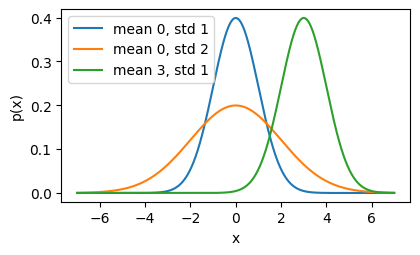

In [13]:
import matplotlib.pyplot as plt
# 再次使用numpy进行可视化
x = np.arange(-7, 7, 0.01)

# 均值和标准差对
params = [(0, 1), (0, 2), (3, 1)]
plt.figure(figsize=(4.5, 2.5))
for mu, sigma in params:
    plt.plot(x, normal(x, mu, sigma), label=f'mean {mu}, std {sigma}')

plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend()
plt.show()

就像我們所看到的，改變均值會產生沿$x$軸的偏移，增加方差將會分散分布、降低其峰值。

均方誤差損失函數（簡稱均方損失）可以用于線性迴歸的一個原因是：
我們假設了觀測中包含噪聲，其中噪聲服從正態分布。
噪聲正態分布如下式:

$$y = \mathbf{w}^\top \mathbf{x} + b + \epsilon,$$

其中，$\epsilon \sim \mathcal{N}(0, \sigma^2)$。

因此，我們現在可以寫出透過給定的$\mathbf{x}$觀測到特定$y$的*似然*（likelihood）：

$$P(y \mid \mathbf{x}) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp\left(-\frac{1}{2 \sigma^2} (y - \mathbf{w}^\top \mathbf{x} - b)^2\right).$$

現在，根據極大似然估計法，參數$\mathbf{w}$和$b$的最優值是使整個資料集的*似然*最大的值：

$$P(\mathbf y \mid \mathbf X) = \prod_{i=1}^{n} p(y^{(i)}|\mathbf{x}^{(i)}).$$

根據極大似然估計法選擇的估計量稱為*極大似然估計量*。
雖然使許多指數函數的乘積最大化看起來很困難，
但是我們可以在不改變目標的前提下，透過最大化似然對數來簡化。
由於歷史原因，優化通常是說最小化而不是最大化。
我們可以改為*最小化負對數似然*$-\log P(\mathbf y \mid \mathbf X)$。
由此可以得到的數學公式是：

$$-\log P(\mathbf y \mid \mathbf X) = \sum_{i=1}^n \frac{1}{2} \log(2 \pi \sigma^2) + \frac{1}{2 \sigma^2} \left(y^{(i)} - \mathbf{w}^\top \mathbf{x}^{(i)} - b\right)^2.$$

現在我們只需要假設$\sigma$是某個固定常數就可以忽略第一項，
因為第一項不依賴於$\mathbf{w}$和$b$。
現在第二項除了常數$\frac{1}{\sigma^2}$外，其餘部分和前面介紹的均方誤差是一樣的。
幸運的是，上面式子的解並不依賴於$\sigma$。
因此，在高斯噪聲的假設下，最小化均方誤差等價於對線性模型的極大似然估計。

## 從線性回歸到深度網路

到目前為止，我們只談論了線性模型。
儘管神經網路涵蓋了更多更豐富的模型，我們依然可以用描述神經網路的方式來描述線性模型，
從而把線性模型看作一個神經網路。
首先，我們用“層”符號來重寫這個模型。

### 神經網路圖

深度學習從業者喜歡繪製圖表來視覺化模型中正在發生的事情。
在 :numref:`fig_single_neuron`中，我們將線性回歸模型描述為一個神經網路。
需要注意的是，該圖只顯示連接模式，即只顯示每個輸入如何連接到輸出，隱去了權重和偏置的值。

![線性回歸是一個單層神經網路。](../img/singleneuron.svg)
:label:`fig_single_neuron`

在 :numref:`fig_single_neuron`所示的神經網路中，輸入為$x_1, \ldots, x_d$，
因此輸入層中的*輸入數*（或稱為*特徵維度*，feature dimensionality）為$d$。
網路的輸出為$o_1$，因此輸出層中的*輸出數*是1。
需要注意的是，輸入值都是已經給定的，並且只有一個*計算*神經元。
由於模型重點在發生計算的地方，所以通常我們在計算層數時不考慮輸入層。
也就是说， :numref:`fig_single_neuron`中神经网络的*层数*为1。
我们可以将线性回归模型视为仅由单个人工神经元组成的神经网络，或称为单层神经网络。

對於線性回歸，每個輸入都與每個輸出（在本例中只有一個輸出）相連，
我們將這種變換（ :numref:`fig_single_neuron`中的輸出層）
稱為*全連接層*（fully-connected layer）或稱為*稠密層*（dense layer）。
下一章將詳細討論由這些層組成的網路。

### 生物學

線性回歸發明時間（1795年）早於計算神經科學，所以將線性回歸描述為神經網路似乎不適合。
當控制學家、神經生物學家沃倫·麥庫洛奇和沃爾特·皮茨開始開發人工神經元模型時，
他們為什麼將線性模型作為起點呢？
我們來看一張圖片 :numref:`fig_Neuron`：
這是一張由*樹突*（dendrites，輸入終端）、
*細胞核*（nucleus，CPU）組成的生物神經元圖片。
*軸突*（axon，輸出線）和*軸突端子*（axon terminal，輸出端子）
透過*突觸*（synapse）與其他神經元連接。

![真實的神經元。](../img/neuron.svg)
:label:`fig_Neuron`

樹突中接收到來自其他神經元（或視網膜等環境傳感器）的信息$x_i$。
該信息透過*突觸權重*$w_i$來加權，以確定輸入的影響（即，透過$x_i w_i$相乘來激活或抑制）。
來自多個源的加權輸入以加權和$y = \sum_i x_i w_i + b$的形式匯聚在細胞核中，
然後將這些信息發送到軸突$y$中進一步處理，通常會透過$\sigma(y)$進行一些非線性處理。
之後，它要么到達目的地（例如肌肉），要么透過樹突進入另一個神經元。

當然，許多這樣的單元可以透過正確的連接和正確的學習算法拼湊在一起，
從而產生的行為比單獨一個神經元所產生的行為更有趣、更複雜，
這種想法歸功於我們對真實生物神經系統的研究。

當今大多數深度學習的研究幾乎沒有直接從神經科學中獲得靈感。
我們援引斯圖爾特·羅素和彼得·諾維格在他們的經典人工智能教科書
*Artificial Intelligence:A Modern Approach* :cite:`Russell.Norvig.2016`
中說的：雖然飛機可能受到鳥類的啟發，但幾個世紀以來，鳥類學並不是航空創新的主要驅動力。
同樣地，如今在深度學習中的靈感同樣或更多地來自數學、統計學和計算機科學。

## 小结

* 機器學習模型中的關鍵要素是訓練資料、損失函數、優化算法，還有模型本身。
* 矢量化使數學表達上更簡潔，同時運行的更快。
* 最小化目標函數和執行極大似然估計等價。
* 線性回歸模型也是一個簡單的神經網路。

## 練習

1. 假設我們有一些資料$x_1, \ldots, x_n \in \mathbb{R}$。我們的目標是找到一個常數$b$，使得最小化$\sum_i (x_i - b)^2$。
    1. 找到最優值$b$的解析解。
    1. 這個問題及其解與正態分布有什麼關係?
1. 推導出使用平方誤差的線性回歸優化問題的解析解。為了簡化問題，可以忽略偏置$b$（我們可以透過向$\mathbf X$添加所有值為1的一列來做到這一點）。
    1. 用矩陣和向量表示法寫出優化問題（將所有資料視為單個矩陣，將所有目標值視為單個向量）。
    1. 計算損失對$w$的梯度。
    1. 透過將梯度設為0、求解矩陣方程來找到解析解。
    1. 什麼時候可能比使用隨機梯度下降更好？這種方法何時會失效？
1. 假定控制附加噪聲$\epsilon$的噪聲模型是指數分布。也就是說，$p(\epsilon) = \frac{1}{2} \exp(-|\epsilon|)$
    1. 寫出模型$-\log P(\mathbf y \mid \mathbf X)$下資料的負對數似然。
    1. 請試著寫出解析解。
    1. 提出一種隨機梯度下降算法來解決這個問題。哪裡可能出錯？（提示：當我們不斷更新參數時，在駐點附近會發生什麼情況）請試著解決這個問題。


---
回答:
1. 假設我們有一些資料$x_1, \ldots, x_n \in \mathbb{R}$。我們的目標是找到一個常數$b$，使得最小化$\sum_i (x_i - b)^2$。
    1. 找到最優值$b$的解析解。
    1. 這個問題及其解與正態分布有什麼關係?
---
**(1.1回答)**  
若要最小化  
$$
\sum_{i=1}^n (x_i - b)^2,
$$  
可以先對 $b$ 取偏微分並設為零以求得最佳解 (解析解)。  
令  
$$
f(b) = \sum_{i=1}^n (x_i - b)^2.
$$  
對 $b$ 取偏微分：  
$$
\frac{\partial}{\partial b} f(b) 
= \frac{\partial}{\partial b} \sum_{i=1}^n (x_i - b)^2 
= \sum_{i=1}^n 2(x_i - b)(-1) 
= -2 \sum_{i=1}^n (x_i - b).
$$  
令此導數為 0：  
$$
-2 \sum_{i=1}^n (x_i - b) = 0 
\quad \Longrightarrow \quad 
\sum_{i=1}^n (x_i - b) = 0 
\quad \Longrightarrow \quad 
\sum_{i=1}^n x_i - nb = 0 
\quad \Longrightarrow \quad 
b = \frac{1}{n} \sum_{i=1}^n x_i.
$$  
因此最佳常數 $b$ 為資料的**平均值**。

---

**(1.2回答)**  
這個問題與正態分布的關係可以從「最大概似估計」(Maximum Likelihood Estimation, MLE) 的觀點來看：  

 1. **正態分布下的假設**  
    假設每個 $x_i$ 都來自同一個常態分布 $N(\mu, \sigma^2)$，但你不知道它的平均數 $\mu$，希望根據樣本 $\{x_1, \ldots, x_n\}$ 來估計最適合的 $\mu$。  
    
2. **最大概似估計**  
正態分布的機率密度函數為  
$$
p(x \mid \mu, \sigma^2) 
= \frac{1}{\sqrt{2\pi}\,\sigma} \exp\!\Bigl( -\frac{(x - \mu)^2}{2\sigma^2} \Bigr).
$$  
如果假設樣本彼此獨立，則總似然函數 (likelihood) 為  
$$
L(\mu, \sigma^2) 
= \prod_{i=1}^n p(x_i \mid \mu, \sigma^2) 
= \left(\frac{1}{\sqrt{2\pi}\,\sigma}\right)^n 
  \exp\!\Bigl( -\frac{1}{2\sigma^2}\sum_{i=1}^n (x_i - \mu)^2 \Bigr).
$$  
為了求 $\mu$ 的最大概似估計，我們通常取對數(稱為 log-likelihood) 以化乘積為加總：  
$$
\ell(\mu, \sigma^2) 
= \log L(\mu, \sigma^2)
= -n \log \sigma 
  - \frac{1}{2\sigma^2}\sum_{i=1}^n (x_i - \mu)^2 
  + \text{(常數)}.
$$  
觀察到要最大化這個對數似然函數，相當於要最小化  
$$
\sum_{i=1}^n (x_i - \mu)^2.
$$  
因此能使得此式最小化的 $\mu$ ，也就是前面我們在最小化平方和時得到的 **平均數**。

3. **結論**  
   - 在最小平方法 (Least Squares) 的觀點下，能最小化誤差平方和的常數就是 **平均值**。  
   - 在正態分布假設下，從最大概似估計 (MLE) 的觀點，最適的平均數估計同樣是樣本的 **平均值**。  

因此，最小平方法 (Minimizing \( \sum_i (x_i - b)^2 \)) 與正態分布假設下的最大概似估計所得的解是一樣的。這也顯示了「最小化平方和」在正態分布中有相當自然的意義：當資料服從高斯分布時，其對應之最適參數（平均數）恰好是樣本平均值。

---
2. 推導出使用平方誤差的線性回歸優化問題的解析解。為了簡化問題，可以忽略偏置$b$（我們可以透過向$\mathbf X$添加所有值為1的一列來做到這一點）。
    1. 用矩陣和向量表示法寫出優化問題（將所有資料視為單個矩陣，將所有目標值視為單個向量）。
    1. 計算損失對$w$的梯度。
    1. 透過將梯度設為0、求解矩陣方程來找到解析解。
    1. 什麼時候可能比使用隨機梯度下降更好？這種方法何時會失效？
---
## 問題設定

給定一組資料點 $\{(\mathbf{x}_i, y_i)\}_{i=1}^n$，其中  
- $\mathbf{x}_i \in \mathbb{R}^d$ 為第 $i$ 筆資料的特徵向量  
- $y_i \in \mathbb{R}$ 為對應的目標值  
 
為了簡化起見，我們「忽略偏置 $b$」；在實際應用中，可以在資料矩陣 $\mathbf{X}$ 的第一列或最後一列額外補上一欄常數 1，將偏置融入參數向量 $\mathbf{w}$。

**線性回歸模型**  
$$
\hat{y}_i = \mathbf{x}_i^\top \mathbf{w},
$$  
其中 $\mathbf{w} \in \mathbb{R}^d$ 是需要學習的參數向量。

我們使用**平方誤差 (Square Error)** 作為損失函式，目標是要  
$$
\min_{\mathbf{w}} \sum_{i=1}^n \bigl(y_i - \mathbf{x}_i^\top \mathbf{w}\bigr)^2.
$$

---

## (回答2.1) 用矩陣和向量表示法寫出優化問題

令  
$$
\mathbf{X} = 
\begin{bmatrix}
- \mathbf{x}_1^\top - \\
- \mathbf{x}_2^\top - \\
\vdots             \\
- \mathbf{x}_n^\top -
\end{bmatrix} 
\in \mathbb{R}^{n \times d},
\quad
\mathbf{y} =
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{bmatrix}
\in \mathbb{R}^{n},
\quad
\mathbf{w} \in \mathbb{R}^d.
$$

那麼，所有資料的**預測值**可寫成  
$$
\hat{\mathbf{y}} = \mathbf{X} \mathbf{w} \in \mathbb{R}^n.
$$

而我們的**損失函式**（以向量形式表示）為  
$$
L(\mathbf{w}) 
= \|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2
= (\mathbf{y} - \mathbf{X}\mathbf{w})^\top (\mathbf{y} - \mathbf{X}\mathbf{w}),
$$  
其中 $\|\cdot\|$ 表示歐幾里得範數（2-範數）。

也可以寫作  
$$
L(\mathbf{w}) 
= \sum_{i=1}^n (y_i - \mathbf{x}_i^\top \mathbf{w})^2.
$$

---

## (回答2.2) 計算損失對 $\mathbf{w}$ 的梯度

針對向量 $\mathbf{w}$，損失函式  
$$
L(\mathbf{w}) 
= (\mathbf{y} - \mathbf{X}\mathbf{w})^\top (\mathbf{y} - \mathbf{X}\mathbf{w})
$$  
對 $\mathbf{w}$ 的梯度為
$$
\nabla_{\mathbf{w}} L(\mathbf{w})
= \nabla_{\mathbf{w}} \bigl[(\mathbf{y} - \mathbf{X}\mathbf{w})^\top (\mathbf{y} - \mathbf{X}\mathbf{w})\bigr].
$$

透過矩陣微分或直接展開可得  
$$
\nabla_{\mathbf{w}} L(\mathbf{w}) 
= -2\, \mathbf{X}^\top \bigl(\mathbf{y} - \mathbf{X}\mathbf{w}\bigr).
$$

（常見結論：$\frac{\partial}{\partial \mathbf{w}} \|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2 
= -2\,\mathbf{X}^\top(\mathbf{y} - \mathbf{X}\mathbf{w})$）

---

## (回答2.3) 透過將梯度設為 0、求解矩陣方程來找到解析解

令梯度為 0，即  
\[
\mathbf{X}^\top \bigl(\mathbf{y} - \mathbf{X}\mathbf{w}\bigr) 
= \mathbf{0}.
\]

可以展開如下：  
\[
\mathbf{X}^\top \mathbf{y} - \mathbf{X}^\top \mathbf{X} \mathbf{w} 
= \mathbf{0}
\;\;\Longrightarrow\;\; 
\mathbf{X}^\top \mathbf{X}\,\mathbf{w} 
= \mathbf{X}^\top \mathbf{y}.
\]

只要 \(\mathbf{X}^\top \mathbf{X}\) 可逆（即可進行矩陣求反），最終得到線性回歸的**解析解** (closed-form solution)：

\[
\mathbf{w}^* 
= (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}.
\]

這個解也常被稱為**正規方程** (Normal Equation)。

---

## (回答2.4) 什麼時候可能比使用隨機梯度下降更好？這種方法何時會失效？

1. **什麼時候可能更好？**  
    - **資料維度與筆數都不算太大**：如果資料量（$n$ 和特徵維度 $d$）都中等或較小，計算 $\mathbf{X}^\top \mathbf{X}$ 以及進行矩陣反轉的成本可接受，便可一次性快速求出**精準解**，省去迭代調參、設置學習率等麻煩。  
    - **需要精確解時**：解析解可以一次直接求出，不必考慮收斂速度、學習率等問題。

2. **什麼時候會失效？**  
    - **$\mathbf{X}^\top \mathbf{X}$ 不可逆或病態 (nearly singular)**：若特徵之間高度共線（multicollinearity），導致 $\mathbf{X}^\top \mathbf{X}$ 近似奇異矩陣，則計算出的結果會非常不穩定甚至無法求逆。此時往往須採用 **正則化** (ridge regression 等) 或使用其他數值穩定的方法。  
    - **資料量/維度非常大**：計算 $\mathbf{X}^\top \mathbf{X}$ 的時間複雜度大約是 $O(nd^2)$，再加上反轉矩陣 $(\mathbf{X}^\top \mathbf{X})$ 是 $O(d^3)$。若 $n$ 和 $d$ 都非常龐大（例如數百萬筆資料、上萬維度），在記憶體和計算時間上都非常昂貴，不如**迭代式方法**（如梯度下降、隨機梯度下降 SGD 或其他優化演算法）更實際、更有效率。

---

### 總結

- **解析解 (closed-form) 的優點**：  
  - 一次求解，精準無需多次迭代；  
  - 對於中小規模問題，計算量可接受。  

- **解析解的缺點**：  
  - 當 $\mathbf{X}^\top \mathbf{X}$ 不可逆或條件數 (condition number) 極差時，數值穩定度低；  
  - 資料量、維度非常大時，計算矩陣反轉的成本過高。

- **隨機梯度下降 (SGD) 或其他迭代法的優點**：  
  - 面對超大規模資料，比較不受記憶體限制；  
  - 可以在線 (online) 不斷更新參數；  
  - 只需用到資料的一部分 (mini-batch) 就能更新參數，學習速度快。  
 
因此，在**中小型數據集**時，使用線性回歸的解析解方法常常更方便；而在**大規模或高維度**資料下，往往需要選擇迭代式的優化方法並結合正則化來解決實務問題。


3. 假定控制附加噪聲$\epsilon$的噪聲模型是指數分布。也就是說，$p(\epsilon) = \frac{1}{2} \exp(-|\epsilon|)$
    1. 寫出模型$-\log P(\mathbf y \mid \mathbf X)$下資料的負對數似然。
    1. 請試著寫出解析解。
    1. 提出一種隨機梯度下降算法來解決這個問題。哪裡可能出錯？（提示：當我們不斷更新參數時，在駐點附近會發生什麼情況）請試著解決這個問題。

---
這邊來一步一步解決這個問題：

1. 寫出負對數似然：

給定 $p(\epsilon) = \frac{1}{2}\exp(-|\epsilon|)$
且 $\epsilon = y - \mathbf{X}\mathbf{w}$ (預測誤差)

負對數似然為：
$$
-\log P(\mathbf{y}|\mathbf{X}) = -\sum\log[\frac{1}{2}\exp(-|y_i - \mathbf{x}_i^\top\mathbf{w}|)]
$$
$$
\phantom{-\log P(\mathbf{y}|\mathbf{X})} = n\log(2) + \sum|y_i - \mathbf{x}_i^\top\mathbf{w}|
$$


2. 解析解：

這個問題沒有簡單的解析解
因為目標函數包含絕對值項$|y_i - x_i^⊤w|$，在0處不可微
這與L1範數優化問題類似


3. 隨機梯度下降算法及其問題：
```python
def sgd_with_laplace_noise(X, y, learning_rate, num_epochs):
    w = np.zeros(X.shape[1])  # 初始化權重
    
    for epoch in range(num_epochs):
        # 隨機選擇mini-batch
        idx = np.random.choice(X.shape[0], batch_size)
        X_batch = X[idx]
        y_batch = y[idx]
        
        # 計算梯度
        errors = y_batch - X_batch.dot(w)
        # 注意：這裡是問題所在
        gradients = -X_batch.T.dot(np.sign(errors))
        
        # 更新權重
        w -= learning_rate * gradients
    
    return w
```

主要問題和解決方案：

1. **梯度不連續問題**：
   - 當誤差接近0時，sign函數在0處不連續
   - 這會導致參數更新震盪，難以收斂

2. **解決方法**：
   - 使用次梯度方法
   - 使用平滑近似，例如：
     ```python
     # 將sign(x)替換為tanh(αx)，α為平滑參數
     gradients = -X_batch.T.dot(np.tanh(alpha * errors))
     ```
   - 使用遞減的學習率
     ```python
     learning_rate = initial_lr / (1 + decay_rate * epoch)
     ```
   - 添加正則化項來增加穩定性

3. **改進的算法**：
```python
def improved_sgd_with_laplace_noise(X, y, initial_lr, num_epochs):
    w = np.zeros(X.shape[1])
    alpha = 10.0  # 平滑參數
    
    for epoch in range(num_epochs):
        # 遞減學習率
        lr = initial_lr / (1 + 0.1 * epoch)
        
        # 隨機選擇mini-batch
        idx = np.random.choice(X.shape[0], batch_size)
        X_batch = X[idx]
        y_batch = y[idx]
        
        # 計算平滑梯度
        errors = y_batch - X_batch.dot(w)
        gradients = -X_batch.T.dot(np.tanh(alpha * errors))
        
        # 添加L2正則化
        gradients += 0.01 * w
        
        # 更新權重
        w -= lr * gradients
        
    return w
```

這個改進版本：
- 使用平滑的tanh代替sign函數
- 採用遞減的學習率
- 添加L2正則化項
- 這些改進可以幫助算法更穩定地收斂

這種問題本質上是L1損失的優化問題，類似於LAD（Least Absolute Deviation）回歸。雖然比L2損失更魯棒，但優化起來更具挑戰性。


[Discussions](https://discuss.d2l.ai/t/1775)
